# Module 7 vNext — Faithful ATCNet-3C for 22×640 EEG

**Goal:** subject-independent 3-class motor-imagery classification on the frozen BCI-IV-2a portion of the project cache using a faithful PyTorch implementation of the published ATCNet structure.

**Input:** `(N, 22, 640)` at 160 Hz, already harmonized/preprocessed by Modules 1–6.

**Outer evaluation:** strict 9-subject BCI-IV-2a LOSO (`S01`…`S09`).

**Architecture:** EEGNet-style convolutional block → 5 overlapping sliding windows → parallel MHA→TCN encoders → average window logits → 3-class head.

The official ATCNet repository reports 81.10% on BCI-IV-2a with its refined Train–Val–Test implementation, and describes ATCNet as a convolutional block plus sliding-window parallel attention/TCN encoders. We adapt only the input length/classes to the project's frozen `(22, 640)` interface; no DANN, MMD, CORAL, FBCSP fusion, or target-domain labels are used in this first pass. See the project cache contract in Modules 5–6 and the official ATCNet implementation.

In [1]:
# ============================================================
# CELL 1 — DETERMINISTIC DEVICE CONFIGURATION
# ============================================================

import os
import random
import numpy as np
import torch

SEED = 42

# ------------------------------------------------------------
# Prefer CPU for reproducibility.
# ------------------------------------------------------------

device = torch.device(
    "cpu"
)

print(
    "Using device:",
    device
)

# ------------------------------------------------------------
# Deterministic seeds.
# ------------------------------------------------------------

def seed_everything(
    seed=SEED
):

    os.environ[
        "PYTHONHASHSEED"
    ] = str(seed)

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(
            seed
        )

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    try:

        torch.use_deterministic_algorithms(
            True
        )

    except Exception as e:

        print(
            "Deterministic algorithms "
            "warning:",
            e
        )


seed_everything()

print(
    "Seed:",
    SEED
)

print(
    "Deterministic mode enabled."
)

# ============================================================
# CELL 1 — IMPORTS / SEEDS / DEVICE
# ============================================================

from __future__ import annotations

import os
import gc
import json
import copy
import math
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import h5py
import scipy.signal as sig
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
)

warnings.filterwarnings("ignore")

SEED = 42


def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything()

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)


Using device: cpu
Seed: 42
Deterministic mode enabled.
Device: mps


In [2]:
# ============================================================
# CELL 2 — PROJECT PATH + FROZEN MODULE 5/6 CONTRACT
# ============================================================

PROJECT_ROOT_CANDIDATES = [
    Path("/Users/ashokvarmabevara/Project2"),
    Path.cwd(),
    Path.home() / "Project2",
    Path("/mnt/data/Project2"),
]

PROJECT_ROOT = None
for p in PROJECT_ROOT_CANDIDATES:
    if (
        (p / "cross_dataset_mi_project").exists()
        or (p / "BCI IV-2a").exists()
    ):
        PROJECT_ROOT = p
        break

if PROJECT_ROOT is None:
    PROJECT_ROOT = Path("/Users/ashokvarmabevara/Project2")

PROJECT_DIR = PROJECT_ROOT / "cross_dataset_mi_project"
CACHE_DIR = PROJECT_DIR / "cache"
MANIFEST_DIR = PROJECT_DIR / "manifests"
RESULT_DIR = PROJECT_DIR / "results" / "module_7_atcnet_vnext"
FIG_DIR = PROJECT_DIR / "figures" / "module_7_atcnet_vnext"
CKPT_DIR = PROJECT_DIR / "checkpoints" / "module_7_atcnet_vnext"

for p in [RESULT_DIR, FIG_DIR, CKPT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

FINAL_CACHE_PATH = CACHE_DIR / "module_5_v2_preprocessed_epochs_160hz_8_30hz_continuous.h5"
MODULE_5_SPEC_PATH = MANIFEST_DIR / "module_5_v2_preprocessing_specification.json"
MODULE_6_META_PATH = MANIFEST_DIR / "module_6_cache_metadata.csv"
MODULE_6_LOSO_PATH = MANIFEST_DIR / "module_6_within_dataset_loso_folds.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("CACHE:", FINAL_CACHE_PATH)

assert FINAL_CACHE_PATH.exists(), f"Missing cache: {FINAL_CACHE_PATH}"
assert MODULE_5_SPEC_PATH.exists(), f"Missing Module 5 spec: {MODULE_5_SPEC_PATH}"

with open(MODULE_5_SPEC_PATH, "r", encoding="utf-8") as f:
    m5 = json.load(f)

FROZEN_CHANNELS = [str(x) for x in m5["channels"]]
TARGET_SFREQ = float(m5["target_sfreq_hz"])
LOW_HZ, HIGH_HZ = map(float, m5["primary_bandpass_hz"])
N_SAMPLES = int(m5["epoch"]["n_samples"])

CLASSES = ["left", "right", "feet"]
CLASS_TO_ID = {c:i for i,c in enumerate(CLASSES)}
ID_TO_CLASS = {i:c for c,i in CLASS_TO_ID.items()}
N_CLASSES = len(CLASSES)

assert len(FROZEN_CHANNELS) == 22
assert TARGET_SFREQ == 160.0
assert (LOW_HZ, HIGH_HZ) == (8.0, 30.0)
assert N_SAMPLES == 640
assert N_CLASSES == 3

print({
    "channels": 22,
    "sampling_rate_hz": TARGET_SFREQ,
    "bandpass_hz": (LOW_HZ, HIGH_HZ),
    "samples": N_SAMPLES,
    "classes": CLASSES,
})


PROJECT_ROOT: /Users/ashokvarmabevara/Project2
CACHE: /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/cache/module_5_v2_preprocessed_epochs_160hz_8_30hz_continuous.h5
{'channels': 22, 'sampling_rate_hz': 160.0, 'bandpass_hz': (8.0, 30.0), 'samples': 640, 'classes': ['left', 'right', 'feet']}


In [3]:
# ============================================================
# CELL 3 — LOAD HDF5 CACHE + METADATA
# ============================================================

REQUIRED_META = [
    "dataset", "subject", "run", "recording_id",
    "filename", "absolute_path", "harmonized_class",
    "event_index", "onset_sec", "source_sfreq_hz"
]


def decode(v):
    if isinstance(v, bytes):
        return v.decode("utf-8")
    return str(v)

with h5py.File(FINAL_CACHE_PATH, "r") as h5:
    X_shape = tuple(h5["X"].shape)
    X_dtype = str(h5["X"].dtype)
    meta_keys = list(h5["metadata"].keys())
    missing = [k for k in REQUIRED_META if k not in meta_keys]

    metadata = {}
    for k in ["dataset","subject","run","recording_id","filename","absolute_path","harmonized_class"]:
        metadata[k] = [decode(v) for v in h5["metadata"][k][:]]
    metadata["event_index"] = h5["metadata"]["event_index"][:].astype(np.int64)
    metadata["onset_sec"] = h5["metadata"]["onset_sec"][:].astype(np.float64)
    metadata["source_sfreq_hz"] = h5["metadata"]["source_sfreq_hz"][:].astype(np.float64)

cache_meta_df = pd.DataFrame(metadata)
cache_meta_df.insert(0, "cache_index", np.arange(len(cache_meta_df), dtype=np.int64))

assert not missing, f"Missing metadata keys: {missing}"
assert X_shape[1:] == (22, 640)
assert X_dtype == "float32"
assert set(cache_meta_df["harmonized_class"].unique()) == set(CLASSES)
assert cache_meta_df["subject"].nunique() == 118

print("Cache shape:", X_shape)
print("Cache dtype:", X_dtype)
print("Subjects:", cache_meta_df["subject"].nunique())

bci_meta = cache_meta_df[cache_meta_df["dataset"] == "BCI-IV-2a"].copy()
BCI_SUBJECTS = sorted(bci_meta["subject"].astype(str).unique())

assert len(BCI_SUBJECTS) == 9, BCI_SUBJECTS

print("BCI-IV-2a subjects:", BCI_SUBJECTS)
print("BCI epochs:", len(bci_meta))

display(
    bci_meta.groupby("subject")["harmonized_class"]
    .value_counts()
    .unstack(fill_value=0)
    .reindex(index=BCI_SUBJECTS, columns=CLASSES, fill_value=0)
)


Cache shape: (9316, 22, 640)
Cache dtype: float32
Subjects: 118
BCI-IV-2a subjects: ['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09']
BCI epochs: 1944


harmonized_class,left,right,feet
subject,,,
S01,72,72,72
S02,72,72,72
S03,72,72,72
S04,72,72,72
S05,72,72,72
S06,72,72,72
S07,72,72,72
S08,72,72,72
S09,72,72,72


In [4]:
# ============================================================
# CELL 4 — HDF5 RANDOM ACCESS + NUMERICAL QA
# ============================================================

class HDF5EpochStore:
    def __init__(self, path):
        self.path = Path(path)
        self._h5 = None

    def __enter__(self):
        self._h5 = h5py.File(self.path, "r")
        return self

    def __exit__(self, exc_type, exc, tb):
        if self._h5 is not None:
            self._h5.close()
            self._h5 = None

    def get_X(self, indices):
        idx = np.asarray(indices, dtype=np.int64)
        order = np.argsort(idx)
        sorted_idx = idx[order]
        values = np.asarray(self._h5["X"][sorted_idx], dtype=np.float32)
        return values[np.argsort(order)]


def load_indices(indices):
    with HDF5EpochStore(FINAL_CACHE_PATH) as store:
        return store.get_X(indices)

# Numerical QA on a deterministic sample.
qa_idx = np.arange(min(512, X_shape[0]), dtype=np.int64)
X_qa = load_indices(qa_idx)

nonfinite = int((~np.isfinite(X_qa)).sum())
epoch_var = np.var(X_qa, axis=(1,2))
zero_var = int((epoch_var <= 1e-12).sum())

print("QA sample shape:", X_qa.shape)
print("Non-finite values:", nonfinite)
print("Zero-variance sample epochs:", zero_var)

assert nonfinite == 0
print("Numerical QA: PASS")


QA sample shape: (512, 22, 640)
Non-finite values: 0
Zero-variance sample epochs: 0
Numerical QA: PASS


In [5]:
# ============================================================
# CELL 5 — INNER SOURCE TRAIN/VALIDATION SPLIT FOR ONE LOSO FOLD
# ============================================================
# The outer test subject remains completely unseen.
# Following the official refined ATCNet Train–Val–Test code,
# model selection uses a 20% validation split from the pooled
# outer-training trials, rather than a second subject holdout.


def split_outer_source_trials(
    train_idx,
    y,
    seed=SEED,
    val_fraction=0.20,
):
    rng = np.random.default_rng(seed)
    train_idx = np.asarray(train_idx, dtype=np.int64)
    y = np.asarray(y, dtype=np.int64)

    if len(train_idx) != len(y):
        raise ValueError("Index/label mismatch")

    train_part = []
    val_part = []

    for cls in range(N_CLASSES):
        cls_idx = train_idx[y == cls]
        rng.shuffle(cls_idx)
        n_val = max(1, int(round(len(cls_idx) * val_fraction)))
        val_part.append(cls_idx[:n_val])
        train_part.append(cls_idx[n_val:])

    train_part = np.concatenate(train_part)
    val_part = np.concatenate(val_part)
    rng.shuffle(train_part)
    rng.shuffle(val_part)
    return train_part, val_part

print("Split helper ready.")


Split helper ready.


In [6]:
# ============================================================
# CELL 6 — SOURCE-ONLY NORMALIZATION
# ============================================================
# A source-only global robust normalization is fitted inside
# every LOSO fold. The outer target is never included in fitting.

class SourceOnlyRobustNormalizer:
    def __init__(self, eps=1e-6):
        self.eps = eps
        self.median_ = None
        self.iqr_ = None

    def fit(self, X):
        X = np.asarray(X, dtype=np.float32)
        values = X.transpose(1,0,2).reshape(X.shape[1], -1).astype(np.float64)
        self.median_ = np.median(values, axis=1)
        q25 = np.percentile(values, 25, axis=1)
        q75 = np.percentile(values, 75, axis=1)
        self.iqr_ = np.maximum(q75 - q25, self.eps)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=np.float32)
        Z = (X - self.median_[None,:,None]) / (self.iqr_[None,:,None] + self.eps)
        return Z.astype(np.float32)

print("Normalizer ready.")


Normalizer ready.


In [7]:
# ============================================================
# CELL 7 — ATCNET: CAUSAL CONV + TCN RESIDUAL BLOCK
# ============================================================

class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, bias=True):
        super().__init__()
        self.pad = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(
            in_ch,
            out_ch,
            kernel_size=kernel_size,
            dilation=dilation,
            padding=self.pad,
            bias=bias,
        )

    def forward(self, x):
        y = self.conv(x)
        if self.pad > 0:
            y = y[..., :-self.pad]
        return y


class TCNResidualBlock(nn.Module):
    """Close PyTorch analogue of ATCNet's TCN_block_."""

    def __init__(self, input_dim, filters=32, depth=2, kernel_size=4, dropout=0.3):
        super().__init__()
        self.blocks = nn.ModuleList()
        self.proj = nn.Conv1d(input_dim, filters, 1) if input_dim != filters else nn.Identity()

        for i in range(depth):
            dilation = 1 if i == 0 else 2 ** i
            self.blocks.append(
                nn.ModuleDict({
                    "c1": CausalConv1d(filters, filters, kernel_size, dilation=dilation),
                    "bn1": nn.BatchNorm1d(filters),
                    "c2": CausalConv1d(filters, filters, kernel_size, dilation=dilation),
                    "bn2": nn.BatchNorm1d(filters),
                    "drop": nn.Dropout(dropout),
                })
            )

    def forward(self, x):
        # x: (B, L, C)
        z = x.transpose(1,2)
        residual = self.proj(z)

        for block in self.blocks:
            h = block["c1"](residual)
            h = block["bn1"](h)
            h = F.elu(h)
            h = block["drop"](h)
            h = block["c2"](h)
            h = block["bn2"](h)
            h = F.elu(h)
            h = block["drop"](h)
            residual = F.elu(h + residual)

        return residual.transpose(1,2)


In [8]:
# ============================================================
# CELL 8 — FAITHFUL ATCNET CONVOLUTIONAL BLOCK
# ============================================================

class ATCNetConvBlock(nn.Module):
    """
    EEGNet-style convolutional block matching the published
    ATCNet flow:
      temporal Conv2D -> depthwise spatial Conv2D -> pool/dropout
      -> refining Conv2D -> pool/dropout

    Input : (B, 1, T, C)
    Output: (B, F2, T_c)
    """

    def __init__(
        self,
        n_channels=22,
        F1=16,
        D=2,
        kernel_size=64,
        pool1=8,
        pool2=7,
        dropout=0.3,
        weight_decay=0.009,
    ):
        super().__init__()

        F2 = F1 * D
        self.F2 = F2

        self.temporal = nn.Conv2d(
            1,
            F1,
            kernel_size=(kernel_size, 1),
            padding=(kernel_size // 2, 0),
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(F1)

        # Spatial depthwise operation across the 22 channels.
        self.spatial = nn.Conv2d(
            F1,
            F2,
            kernel_size=(1, n_channels),
            groups=F1,
            bias=False,
        )
        self.bn2 = nn.BatchNorm2d(F2)
        self.pool1 = nn.AvgPool2d((pool1, 1))
        self.drop1 = nn.Dropout(dropout)

        self.refine = nn.Conv2d(
            F2,
            F2,
            kernel_size=(16, 1),
            padding=(8, 0),
            bias=False,
        )
        self.bn3 = nn.BatchNorm2d(F2)
        self.pool2 = nn.AvgPool2d((pool2, 1))
        self.drop2 = nn.Dropout(dropout)

    def forward(self, x):
        # x = (B,C,T)
        x = x.unsqueeze(1).transpose(2,3)   # (B,1,T,C)

        z = self.temporal(x)
        z = self.bn1(z)

        z = self.spatial(z)
        z = self.bn2(z)
        z = F.elu(z)
        z = self.pool1(z)
        z = self.drop1(z)

        z = self.refine(z)
        z = self.bn3(z)
        z = F.elu(z)
        z = self.pool2(z)
        z = self.drop2(z)

        # Because the spatial dimension is now 1.
        z = z.squeeze(-1)  # (B,F2,Tc)
        z = z.transpose(1,2)  # (B,Tc,F2)
        return z


In [9]:
# ============================================================
# CELL 9 — FAITHFUL ATCNET-3C MODEL
# ============================================================

class ATCNet3C(nn.Module):
    """
    Faithful ATCNet adapted only for:
      - 3 classes
      - 22 channels
      - 640 samples

    Architecture:
      Conv block
      -> 5 shifted overlapping windows
      -> MHA
      -> TCN residual stack
      -> last timestep
      -> 3-class logits per window
      -> average window logits
    """

    def __init__(
        self,
        n_classes=3,
        n_channels=22,
        n_samples=640,
        n_windows=5,
        F1=16,
        D=2,
        kernel_size=64,
        pool1=8,
        pool2=7,
        attn_heads=2,
        attn_dropout=0.3,
        tcn_depth=2,
        tcn_kernel=4,
        tcn_filters=32,
        tcn_dropout=0.3,
        dropout=0.3,
    ):
        super().__init__()

        self.n_windows = n_windows
        self.n_classes = n_classes
        self.n_samples = n_samples
        self.F2 = F1 * D

        self.conv_block = ATCNetConvBlock(
            n_channels=n_channels,
            F1=F1,
            D=D,
            kernel_size=kernel_size,
            pool1=pool1,
            pool2=pool2,
            dropout=dropout,
        )

        self.attention_blocks = nn.ModuleList([
            nn.MultiheadAttention(
                embed_dim=self.F2,
                num_heads=attn_heads,
                dropout=attn_dropout,
                batch_first=True,
            )
            for _ in range(n_windows)
        ])

        self.attn_norms = nn.ModuleList([
            nn.LayerNorm(self.F2)
            for _ in range(n_windows)
        ])

        self.tcn_blocks = nn.ModuleList([
            TCNResidualBlock(
                input_dim=self.F2,
                filters=tcn_filters,
                depth=tcn_depth,
                kernel_size=tcn_kernel,
                dropout=tcn_dropout,
            )
            for _ in range(n_windows)
        ])

        self.window_heads = nn.ModuleList([
            nn.Linear(tcn_filters, n_classes)
            for _ in range(n_windows)
        ])

        # Determine condensed sequence length for diagnostics.
        with torch.no_grad():
            dummy = torch.zeros(2, n_channels, n_samples)
            seq = self.conv_block(dummy)
            self.condensed_length = seq.shape[1]
            self.window_length = seq.shape[1] - n_windows + 1

    def forward(self, x):
        seq = self.conv_block(x)  # (B,Tc,F2)
        B, Tc, C = seq.shape

        if self.window_length <= 0:
            raise RuntimeError(
                f"Invalid sliding windows: condensed_length={Tc}, n_windows={self.n_windows}"
            )

        logits = []

        for i in range(self.n_windows):
            start = i
            end = Tc - self.n_windows + i + 1
            w = seq[:, start:end, :]

            # MHA + residual + LayerNorm.
            attn_out, _ = self.attention_blocks[i](w, w, w, need_weights=False)
            w = self.attn_norms[i](w + attn_out)

            # TCN sees temporal sequence.
            w = self.tcn_blocks[i](w)

            last = w[:, -1, :]
            logits.append(
                self.window_heads[i](last)
            )

        return torch.stack(logits, dim=0).mean(dim=0)


# ------------------------------------------------------------
# Instantiate / shape test.
# ------------------------------------------------------------

_test_model = ATCNet3C(
    n_classes=3,
    n_channels=22,
    n_samples=640,
)

n_params = sum(
    p.numel() for p in _test_model.parameters() if p.requires_grad
)

print("Condensed length:", _test_model.condensed_length)
print("Window length:", _test_model.window_length)
print("Trainable parameters:", f"{n_params:,}")

with torch.no_grad():
    dummy = torch.randn(2,22,640)
    dummy_logits = _test_model(dummy)

print("Output shape:", tuple(dummy_logits.shape))
assert dummy_logits.shape == (2,3)
print("ATCNet forward test: PASS")


Condensed length: 11
Window length: 7
Trainable parameters: 124,047
Output shape: (2, 3)
ATCNet forward test: PASS


In [10]:
# ============================================================
# CELL 10 — EEG AUGMENTATION + BALANCED/EVAL LOADERS
# ============================================================

def augment_mi_eeg(x):
    """
    Mild EEG augmentation.

    Designed to preserve motor-imagery structure while
    reducing sensitivity to amplitude and timing variations.
    """

    x = x.clone()

    B, C, T = x.shape

    # --------------------------------------------------------
    # Global amplitude jitter
    # --------------------------------------------------------

    if torch.rand(
        1,
        device=x.device,
    ).item() < 0.35:

        scale = torch.empty(
            B,
            1,
            1,
            device=x.device,
        ).uniform_(
            0.90,
            1.10,
        )

        x = x * scale

    # --------------------------------------------------------
    # Small channel gain perturbation
    # --------------------------------------------------------

    if torch.rand(
        1,
        device=x.device,
    ).item() < 0.25:

        gain = torch.empty(
            B,
            C,
            1,
            device=x.device,
        ).uniform_(
            0.97,
            1.03,
        )

        x = x * gain

    # --------------------------------------------------------
    # Very small sensor noise
    # --------------------------------------------------------

    if torch.rand(
        1,
        device=x.device,
    ).item() < 0.25:

        x = (
            x
            + 0.005
            * torch.randn_like(
                x
            )
        )

    # --------------------------------------------------------
    # Very small temporal translation
    # --------------------------------------------------------

    if torch.rand(
        1,
        device=x.device,
    ).item() < 0.20:

        max_shift = max(
            1,
            int(
                0.015
                * T
            ),
        )

        shifts = torch.randint(
            -max_shift,
            max_shift + 1,
            (
                B,
            ),
            device=x.device,
        )

        x = torch.stack(
            [
                torch.roll(
                    x[i],
                    int(
                        shifts[i].item()
                    ),
                    dims=-1,
                )
                for i in range(B)
            ],
            dim=0,
        )

    return x


# ============================================================
# CLASS-BALANCED TRAIN LOADER
# ============================================================

def make_class_balanced_loader(
    X,
    y,
    batch_size=64,
):

    X = np.asarray(
        X,
        dtype=np.float32,
    )

    y = np.asarray(
        y,
        dtype=np.int64,
    )

    if X.ndim != 3:
        raise ValueError(
            f"Expected X=(N,C,T), got {X.shape}"
        )

    if X.shape[1:] != (
        22,
        640,
    ):
        raise ValueError(
            f"Expected (N,22,640), got {X.shape}"
        )

    if len(X) != len(y):
        raise ValueError(
            "X/y length mismatch."
        )

    ds = TensorDataset(
        torch.from_numpy(X),
        torch.from_numpy(y),
    )

    counts = np.bincount(
        y,
        minlength=N_CLASSES,
    ).astype(
        np.float64
    )

    inv = np.zeros_like(
        counts
    )

    valid = (
        counts > 0
    )

    inv[valid] = (
        1.0
        /
        counts[valid]
    )

    sample_weights = (
        inv[y]
    )

    sampler = WeightedRandomSampler(
        torch.as_tensor(
            sample_weights,
            dtype=torch.double,
        ),
        num_samples=len(y),
        replacement=True,
    )

    return DataLoader(
        ds,
        batch_size=batch_size,
        sampler=sampler,
        drop_last=False,
        num_workers=0,
        pin_memory=(
            torch.cuda.is_available()
        ),
    )


# ============================================================
# DETERMINISTIC EVAL LOADER
# ============================================================

def make_eval_loader(
    X,
    batch_size=128,
):

    X = np.asarray(
        X,
        dtype=np.float32,
    )

    if X.ndim != 3:
        raise ValueError(
            f"Expected X=(N,C,T), got {X.shape}"
        )

    ds = TensorDataset(
        torch.from_numpy(X),
        torch.zeros(
            len(X),
            dtype=torch.long,
        ),
    )

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        num_workers=0,
        pin_memory=(
            torch.cuda.is_available()
        ),
    )


print(
    "✅ Cell 10 ready."
)

✅ Cell 10 ready.


In [11]:
# ============================================================
# CELL 11 — STABLE MULTI-SEED ATCNET TRAINING
# ============================================================

ATCNET_ENSEMBLE_SEEDS = (
    42,
    123,
)

# Use 3 seeds if compute time allows:
# ATCNET_ENSEMBLE_SEEDS = (42, 123, 777)


def model_predict(
    model,
    X,
    batch_size=128,
):
    """
    Return class probabilities only.
    """

    model.eval()

    loader = make_eval_loader(
        X,
        batch_size=batch_size,
    )

    outputs = []

    with torch.no_grad():

        for xb, _ in loader:

            xb = xb.to(
                device,
                non_blocking=True,
            )

            logits = model(
                xb
            )

            if isinstance(
                logits,
                tuple,
            ):

                logits = logits[0]

            outputs.append(
                logits.detach()
                .cpu()
                .numpy()
            )

    logits = np.concatenate(
        outputs,
        axis=0,
    )

    logits -= (
        logits.max(
            axis=1,
            keepdims=True,
        )
    )

    probs = np.exp(
        logits
    )

    probs /= (
        probs.sum(
            axis=1,
            keepdims=True,
        )
        + 1e-12
    )

    return probs


def apply_max_norm_constraints(
    model,
    max_norm=0.6,
):
    """
    Approximate reference ATCNet max-norm constraint.
    """

    with torch.no_grad():

        for module in model.modules():

            if isinstance(
                module,
                (
                    nn.Conv1d,
                    nn.Conv2d,
                    nn.Linear,
                ),
            ):

                if module.weight is None:
                    continue

                W = (
                    module.weight.data
                )

                flat = W.reshape(
                    W.shape[0],
                    -1,
                )

                norms = (
                    flat
                    .norm(
                        p=2,
                        dim=1,
                        keepdim=True,
                    )
                    .clamp_min(
                        1e-8
                    )
                )

                scale = torch.clamp(
                    max_norm
                    / norms,
                    max=1.0,
                )

                flat.mul_(
                    scale
                )


def train_atcnet_one_seed(
    X_train,
    y_train,
    X_val,
    y_val,
    seed,
    epochs=180,
    batch_size=64,
    lr=9e-4,
    patience=35,
):
    """
    Train one independent ATCNet.

    Best checkpoint is selected using SOURCE validation loss.
    """

    seed_everything(
        seed
    )

    model = ATCNet3C(
        n_classes=3,
        n_channels=22,
        n_samples=640,
        n_windows=5,
        F1=16,
        D=2,
        kernel_size=64,
        pool1=8,
        pool2=7,
        attn_heads=2,
        attn_dropout=0.3,
        tcn_depth=2,
        tcn_kernel=4,
        tcn_filters=32,
        tcn_dropout=0.3,
        dropout=0.3,
    ).to(device)

    # --------------------------------------------------------
    # Class-balanced loss
    # --------------------------------------------------------

    counts = np.bincount(
        y_train,
        minlength=N_CLASSES,
    ).astype(
        np.float32
    )

    class_w = (
        counts.sum()
        /
        (
            N_CLASSES
            *
            np.maximum(
                counts,
                1.0,
            )
        )
    )

    class_w = (
        class_w
        /
        (
            class_w.mean()
            + 1e-12
        )
    )

    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(
            class_w,
            dtype=torch.float32,
            device=device,
        ),
        label_smoothing=0.01,
    )

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
    )

    # --------------------------------------------------------
    # Reference-style scheduler
    # --------------------------------------------------------

    scheduler = (
        optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.90,
            patience=15,
            min_lr=1e-5,
        )
    )

    loader = make_class_balanced_loader(
        X_train,
        y_train,
        batch_size=batch_size,
    )

    best_state = None
    best_val_loss = np.inf
    best_val_bacc = -np.inf
    best_epoch = 0
    wait = 0

    history = []

    print(
        "\n"
        + "-" * 72
    )

    print(
        f"ATCNet seed = {seed}"
    )

    print(
        "-" * 72
    )

    # ========================================================
    # TRAIN
    # ========================================================

    for epoch in range(
        1,
        epochs + 1,
    ):

        model.train()

        epoch_losses = []

        train_true = []
        train_pred = []

        for xb, yb in loader:

            xb = xb.to(
                device,
                non_blocking=True,
            )

            yb = yb.to(
                device,
                non_blocking=True,
            )

            xb = augment_mi_eeg(
                xb
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            output = model(
                xb
            )

            if isinstance(
                output,
                tuple,
            ):

                logits = output[0]

            else:

                logits = output

            loss = criterion(
                logits,
                yb,
            )

            if not torch.isfinite(
                loss
            ):

                continue

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0,
            )

            optimizer.step()

            apply_max_norm_constraints(
                model,
                max_norm=0.6,
            )

            epoch_losses.append(
                float(
                    loss.item()
                )
            )

            train_true.extend(
                yb.detach()
                .cpu()
                .numpy()
            )

            train_pred.extend(
                logits.argmax(
                    1
                )
                .detach()
                .cpu()
                .numpy()
            )

        # ----------------------------------------------------
        # Validation
        # ----------------------------------------------------

        P_val = model_predict(
            model,
            X_val,
        )

        val_pred = (
            P_val.argmax(
                axis=1
            )
        )

        eps = 1e-8

        val_loss = -np.mean(
            np.log(
                np.clip(
                    P_val[
                        np.arange(
                            len(y_val)
                        ),
                        y_val,
                    ],
                    eps,
                    1.0,
                )
            )
        )

        train_acc = (
            accuracy_score(
                train_true,
                train_pred,
            )
            * 100.0
        )

        val_acc = (
            accuracy_score(
                y_val,
                val_pred,
            )
            * 100.0
        )

        val_bacc = (
            balanced_accuracy_score(
                y_val,
                val_pred,
            )
            * 100.0
        )

        scheduler.step(
            val_loss
        )

        history.append(
            {
                "epoch":
                    epoch,

                "train_loss":
                    float(
                        np.mean(
                            epoch_losses
                        )
                    ),

                "val_loss":
                    float(
                        val_loss
                    ),

                "train_acc":
                    train_acc,

                "val_acc":
                    val_acc,

                "val_bacc":
                    val_bacc,

                "lr":
                    optimizer.param_groups[
                        0
                    ]["lr"],
            }
        )

        # ----------------------------------------------------
        # Checkpoint
        # ----------------------------------------------------

        if (
            val_loss
            <
            best_val_loss
            - 1e-5
        ):

            best_val_loss = (
                val_loss
            )

            best_val_bacc = (
                val_bacc
            )

            best_epoch = (
                epoch
            )

            wait = 0

            best_state = (
                copy.deepcopy(
                    model.state_dict()
                )
            )

        else:

            wait += 1

        if (
            epoch == 1
            or epoch % 10 == 0
        ):

            print(
                f"    epoch {epoch:03d} | "
                f"train={train_acc:5.1f}% | "
                f"val={val_acc:5.1f}% | "
                f"bAcc={val_bacc:5.1f}% | "
                f"vLoss={val_loss:.4f} | "
                f"lr={optimizer.param_groups[0]['lr']:.2e}"
            )

        if wait >= patience:

            print(
                f"    early stop at "
                f"epoch {epoch}; "
                f"best={best_epoch}"
            )

            break

    # --------------------------------------------------------
    # Restore best checkpoint
    # --------------------------------------------------------

    if best_state is not None:

        model.load_state_dict(
            best_state
        )

    history_df = pd.DataFrame(
        history
    )

    print(
        f"    best val loss  = "
        f"{best_val_loss:.4f}"
    )

    print(
        f"    best val bAcc  = "
        f"{best_val_bacc:.2f}%"
    )

    print(
        f"    best epoch     = "
        f"{best_epoch}"
    )

    return (
        model,
        history_df,
        best_epoch,
        best_val_loss,
        best_val_bacc,
    )


def train_atcnet_ensemble(
    X_train,
    y_train,
    X_val,
    y_val,
    seeds=ATCNET_ENSEMBLE_SEEDS,
):
    """
    Train independent ATCNet models.
    """

    models = []
    histories = []
    summary = []

    for seed in seeds:

        model, hist, epoch, vloss, vbacc = (
            train_atcnet_one_seed(
                X_train,
                y_train,
                X_val,
                y_val,
                seed=seed,
            )
        )

        models.append(
            model
        )

        histories.append(
            hist
        )

        summary.append(
            {
                "seed":
                    seed,

                "best_epoch":
                    epoch,

                "best_val_loss":
                    vloss,

                "best_val_bacc":
                    vbacc,
            }
        )

        gc.collect()

        if torch.cuda.is_available():

            torch.cuda.empty_cache()

    summary_df = pd.DataFrame(
        summary
    )

    print(
        "\nSeed summary:"
    )

    display(
        summary_df
    )

    return (
        models,
        histories,
        summary_df,
    )


def ensemble_predict(
    models,
    X,
):
    """
    Average probabilities from all trained seeds.
    """

    probabilities = []

    for model in models:

        P = model_predict(
            model,
            X,
        )

        probabilities.append(
            P
        )

    P_mean = np.mean(
        np.stack(
            probabilities,
            axis=0,
        ),
        axis=0,
    )

    P_mean /= (
        P_mean.sum(
            axis=1,
            keepdims=True,
        )
        + 1e-12
    )

    return P_mean


print(
    "✅ Cell 11 ready."
)

✅ Cell 11 ready.


In [12]:
# ============================================================
# CELL 12 — LOSO FOLD WITH MULTI-SEED ENSEMBLE + TTA
# ============================================================

def temporal_tta_predict(
    models,
    X,
    shifts=(
        -32,
        -16,
        0,
        16,
        32,
    ),
):
    """
    Fixed temporal test-time augmentation.

    No target labels are used.
    """

    X = np.asarray(
        X,
        dtype=np.float32,
    )

    all_views = []

    for shift in shifts:

        if shift == 0:

            X_view = X.copy()

        else:

            X_view = np.roll(
                X,
                shift,
                axis=-1,
            )

        P = ensemble_predict(
            models,
            X_view,
        )

        all_views.append(
            P
        )

    P_final = np.mean(
        np.stack(
            all_views,
            axis=0,
        ),
        axis=0,
    )

    P_final /= (
        P_final.sum(
            axis=1,
            keepdims=True,
        )
        + 1e-12
    )

    return P_final


def run_bci_loso_fold(
    target_subject,
    fold_id,
    epochs=180,
    batch_size=64,
    lr=9e-4,
    patience=35,
):
    """
    Strict within-dataset LOSO.

    Target subject:
        completely unseen during training.

    Source:
        remaining 8 subjects.

    The final target prediction is produced by:
        1. multiple ATCNet seeds
        2. probability averaging
        3. temporal TTA
    """

    t0 = time.time()

    target_subject = str(
        target_subject
    )

    # ========================================================
    # BCI METADATA
    # ========================================================

    bci = cache_meta_df[
        cache_meta_df[
            "dataset"
        ].astype(str)
        == "BCI-IV-2a"
    ].copy()

    bci["subject"] = (
        bci["subject"]
        .astype(str)
    )

    # ========================================================
    # OUTER LOSO
    # ========================================================

    source_mask = (
        bci["subject"]
        != target_subject
    )

    target_mask = (
        bci["subject"]
        == target_subject
    )

    source_idx = (
        bci.loc[
            source_mask,
            "cache_index",
        ]
        .to_numpy(
            dtype=np.int64
        )
    )

    target_idx = (
        bci.loc[
            target_mask,
            "cache_index",
        ]
        .to_numpy(
            dtype=np.int64
        )
    )

    X_source_raw = load_indices(
        source_idx
    )

    X_test_raw = load_indices(
        target_idx
    )

    y_source = (
        bci.loc[
            source_mask,
            "harmonized_class",
        ]
        .map(
            CLASS_TO_ID
        )
        .to_numpy(
            dtype=np.int64
        )
    )

    y_test = (
        bci.loc[
            target_mask,
            "harmonized_class",
        ]
        .map(
            CLASS_TO_ID
        )
        .to_numpy(
            dtype=np.int64
        )
    )

    # ========================================================
    # SOURCE-ONLY NORMALIZATION
    # ========================================================

    normalizer = (
        SourceOnlyRobustNormalizer()
        .fit(
            X_source_raw
        )
    )

    X_source_n = (
        normalizer.transform(
            X_source_raw
        )
    )

    X_test_n = (
        normalizer.transform(
            X_test_raw
        )
    )

    X_source_n = (
        np.nan_to_num(
            X_source_n,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )
        .astype(
            np.float32
        )
    )

    X_test_n = (
        np.nan_to_num(
            X_test_n,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )
        .astype(
            np.float32
        )
    )

    # ========================================================
    # SOURCE TRAIN / VALIDATION SPLIT
    # ========================================================

    train_idx_local, val_idx_local = (
        split_outer_source_trials(
            np.arange(
                len(
                    X_source_n
                )
            ),
            y_source,
            seed=SEED,
            val_fraction=0.20,
        )
    )

    X_train = (
        X_source_n[
            train_idx_local
        ]
    )

    y_train = (
        y_source[
            train_idx_local
        ]
    )

    X_val = (
        X_source_n[
            val_idx_local
        ]
    )

    y_val = (
        y_source[
            val_idx_local
        ]
    )

    # ========================================================
    # REPORT
    # ========================================================

    print(
        "\n"
        + "=" * 78
    )

    print(
        f"BCI-IV-2a LOSO "
        f"[{fold_id}/9] — target {target_subject}"
    )

    print(
        "=" * 78
    )

    print(
        "Source trials:",
        len(X_source_n)
    )

    print(
        "Train trials :",
        len(X_train)
    )

    print(
        "Val trials   :",
        len(X_val)
    )

    print(
        "Test trials  :",
        len(X_test_n)
    )

    print(
        "Ensemble seeds:",
        ATCNET_ENSEMBLE_SEEDS
    )

    # ========================================================
    # MULTI-SEED TRAINING
    # ========================================================

    (
        models,
        histories,
        seed_summary,
    ) = train_atcnet_ensemble(
        X_train,
        y_train,
        X_val,
        y_val,
        seeds=ATCNET_ENSEMBLE_SEEDS,
    )

    # ========================================================
    # VALIDATION ENSEMBLE
    # ========================================================

    P_val = (
        ensemble_predict(
            models,
            X_val,
        )
    )

    val_pred = (
        P_val.argmax(
            axis=1
        )
    )

    val_acc = (
        accuracy_score(
            y_val,
            val_pred,
        )
        * 100.0
    )

    val_bacc = (
        balanced_accuracy_score(
            y_val,
            val_pred,
        )
        * 100.0
    )

    print(
        "\nEnsemble source validation:"
    )

    print(
        f"Accuracy : "
        f"{val_acc:.2f}%"
    )

    print(
        f"BAcc     : "
        f"{val_bacc:.2f}%"
    )

    # ========================================================
    # STANDARD TEST
    # ========================================================

    P_test = (
        ensemble_predict(
            models,
            X_test_n,
        )
    )

    pred_test = (
        P_test.argmax(
            axis=1
        )
    )

    standard_acc = (
        accuracy_score(
            y_test,
            pred_test,
        )
        * 100.0
    )

    standard_bacc = (
        balanced_accuracy_score(
            y_test,
            pred_test,
        )
        * 100.0
    )

    # ========================================================
    # TEMPORAL TTA TEST
    # ========================================================

    P_test_tta = (
        temporal_tta_predict(
            models,
            X_test_n,
        )
    )

    pred_test_tta = (
        P_test_tta.argmax(
            axis=1
        )
    )

    tta_acc = (
        accuracy_score(
            y_test,
            pred_test_tta,
        )
        * 100.0
    )

    tta_bacc = (
        balanced_accuracy_score(
            y_test,
            pred_test_tta,
        )
        * 100.0
    )

    kappa_standard = (
        cohen_kappa_score(
            y_test,
            pred_test,
        )
    )

    kappa_tta = (
        cohen_kappa_score(
            y_test,
            pred_test_tta,
        )
    )

    # ========================================================
    # FIXED SELECTION RULE
    # ========================================================
    #
    # TTA is fixed before test evaluation.
    # We do NOT select whichever test result is higher.
    #
    # TTA is the predefined final method.
    # ========================================================

    final_P = (
        P_test_tta
    )

    final_pred = (
        pred_test_tta
    )

    final_acc = (
        tta_acc
    )

    final_bacc = (
        tta_bacc
    )

    final_kappa = (
        kappa_tta
    )

    elapsed = (
        time.time()
        - t0
    )

    # ========================================================
    # REPORT
    # ========================================================

    print(
        "\n"
        + "-" * 78
    )

    print(
        f"Target subject       : "
        f"{target_subject}"
    )

    print(
        f"Validation ensemble  : "
        f"{val_bacc:.2f}%"
    )

    print(
        f"Standard ensemble    : "
        f"{standard_acc:.2f}%"
    )

    print(
        f"Standard ensemble bA : "
        f"{standard_bacc:.2f}%"
    )

    print(
        f"TTA ensemble         : "
        f"{tta_acc:.2f}%"
    )

    print(
        f"TTA ensemble bAcc    : "
        f"{tta_bacc:.2f}%"
    )

    print(
        f"TTA kappa            : "
        f"{kappa_tta:.4f}"
    )

    print(
        f"Elapsed              : "
        f"{elapsed / 60.0:.1f} min"
    )

    print(
        "-" * 78
    )

    return {
        "fold":
            fold_id,

        "subject":
            target_subject,

        "test_acc":
            final_acc,

        "test_bacc":
            final_bacc,

        "standard_acc":
            standard_acc,

        "standard_bacc":
            standard_bacc,

        "tta_acc":
            tta_acc,

        "tta_bacc":
            tta_bacc,

        "kappa":
            final_kappa,

        "standard_kappa":
            kappa_standard,

        "best_epoch":
            int(
                seed_summary[
                    "best_epoch"
                ].mean()
            ),

        "val_acc":
            val_acc,

        "val_bacc":
            val_bacc,

        "P_test":
            final_P,

        "pred_test":
            final_pred,

        "y_test":
            y_test,

        "histories":
            histories,

        "seed_summary":
            seed_summary,

        "models":
            models,

        "normalizer":
            normalizer,
    }


print(
    "✅ Cell 12 ready."
)

✅ Cell 12 ready.


In [13]:
# ============================================================
# CELL 13 — MULTI-SEED S01 SMOKE TEST
# ============================================================

RUN_SMOKE = True

if RUN_SMOKE:

    smoke_result = (
        run_bci_loso_fold(
            target_subject="S01",
            fold_id=1,
            epochs=180,
            batch_size=64,
            lr=9e-4,
            patience=35,
        )
    )

    print(
        "\n" + "=" * 78
    )

    print(
        "MULTI-SEED S01 SMOKE TEST"
    )

    print(
        "=" * 78
    )

    print(
        f"S01 standard ensemble : "
        f"{smoke_result['standard_acc']:.2f}%"
    )

    print(
        f"S01 TTA ensemble      : "
        f"{smoke_result['tta_acc']:.2f}%"
    )

    print(
        f"S01 final accuracy    : "
        f"{smoke_result['test_acc']:.2f}%"
    )

    print(
        f"S01 final bAcc        : "
        f"{smoke_result['test_bacc']:.2f}%"
    )


BCI-IV-2a LOSO [1/9] — target S01
Source trials: 1728
Train trials : 1383
Val trials   : 345
Test trials  : 216
Ensemble seeds: (42, 123)

------------------------------------------------------------------------
ATCNet seed = 42
------------------------------------------------------------------------
    epoch 001 | train= 37.9% | val= 45.5% | bAcc= 45.5% | vLoss=1.0577 | lr=9.00e-04
    epoch 010 | train= 59.9% | val= 59.4% | bAcc= 59.4% | vLoss=0.8224 | lr=9.00e-04
    epoch 020 | train= 71.4% | val= 60.3% | bAcc= 60.3% | vLoss=0.8476 | lr=9.00e-04
    epoch 030 | train= 72.6% | val= 65.2% | bAcc= 65.2% | vLoss=0.7569 | lr=9.00e-04
    epoch 040 | train= 78.4% | val= 65.5% | bAcc= 65.5% | vLoss=0.7634 | lr=9.00e-04
    epoch 050 | train= 79.8% | val= 67.5% | bAcc= 67.5% | vLoss=0.7189 | lr=8.10e-04
    epoch 060 | train= 83.3% | val= 70.1% | bAcc= 70.1% | vLoss=0.7155 | lr=8.10e-04
    epoch 070 | train= 86.1% | val= 65.2% | bAcc= 65.2% | vLoss=0.7956 | lr=8.10e-04
    epoch 080 | t

,seed,best_epoch,best_val_loss,best_val_bacc
0,42,58,0.674398,71.304348
1,123,54,0.602125,76.521739



Ensemble source validation:
Accuracy : 75.94%
BAcc     : 75.94%

------------------------------------------------------------------------------
Target subject       : S01
Validation ensemble  : 75.94%
Standard ensemble    : 79.17%
Standard ensemble bA : 79.17%
TTA ensemble         : 79.17%
TTA ensemble bAcc    : 79.17%
TTA kappa            : 0.6875
Elapsed              : 25.5 min
------------------------------------------------------------------------------

MULTI-SEED S01 SMOKE TEST
S01 standard ensemble : 79.17%
S01 TTA ensemble      : 79.17%
S01 final accuracy    : 79.17%
S01 final bAcc        : 79.17%


In [18]:
# ============================================================
# CELL 14 — FULL 9-SUBJECT ATCNET-3C LOSO
# MULTI-SEED ENSEMBLE
# ============================================================
#
# Frozen configuration after S01 smoke test:
#
#   Architecture : faithful ATCNet-3C
#   Seeds        : 42, 123
#   LR           : 9e-4
#   Epochs       : 180
#   Patience     : 35
#   TTA          : OFF
#
# Evaluation:
#   Strict BCI-IV-2a LOSO
#   One subject completely held out at a time.
#
# ============================================================

RUN_FULL_LOSO = True

# ------------------------------------------------------------
# BCI subjects
# ------------------------------------------------------------

if "BCI_SUBJECTS" in globals():

    subjects = sorted(
        [
            str(s)
            for s in BCI_SUBJECTS
        ]
    )

else:

    subjects = sorted(
        cache_meta_df.loc[
            cache_meta_df[
                "dataset"
            ]
            .astype(str)
            == "BCI-IV-2a",
            "subject",
        ]
        .astype(str)
        .unique()
    )


# ------------------------------------------------------------
# Verify exactly 9 subjects
# ------------------------------------------------------------

print(
    "=" * 78
)

print(
    "ATCNet-3C — FULL BCI-IV-2a LOSO"
)

print(
    "=" * 78
)

print(
    "Subjects:",
    subjects
)

print(
    "Number of subjects:",
    len(subjects)
)

print(
    "Ensemble seeds:",
    ATCNET_ENSEMBLE_SEEDS
)

assert len(subjects) == 9, (
    f"Expected 9 BCI-IV-2a subjects, "
    f"found {len(subjects)}"
)


# ------------------------------------------------------------
# Results containers
# ------------------------------------------------------------

all_results = []

fold_objects = {}


# ============================================================
# RUN LOSO
# ============================================================

if RUN_FULL_LOSO:

    for fold_id, target_subject in enumerate(
        subjects,
        start=1,
    ):

        print(
            "\n"
            + "=" * 78
        )

        print(
            f"Starting fold "
            f"{fold_id}/9 "
            f"— target {target_subject}"
        )

        print(
            "=" * 78
        )

        result = run_bci_loso_fold(
            target_subject=target_subject,
            fold_id=fold_id,
            epochs=180,
            batch_size=64,
            lr=9e-4,
            patience=35,
        )

        # ----------------------------------------------------
        # Store complete fold object
        # ----------------------------------------------------

        fold_objects[
            target_subject
        ] = result

        # ----------------------------------------------------
        # Store compact results
        # ----------------------------------------------------

        all_results.append(
            {
                "fold":
                    fold_id,

                "subject":
                    target_subject,

                "standard_accuracy":
                    float(
                        result[
                            "standard_acc"
                        ]
                    ),

                "standard_bacc":
                    float(
                        result[
                            "standard_bacc"
                        ]
                    ),

                "tta_accuracy":
                    float(
                        result[
                            "tta_acc"
                        ]
                    ),

                "tta_bacc":
                    float(
                        result[
                            "tta_bacc"
                        ]
                    ),

                "accuracy":
                    float(
                        result[
                            "test_acc"
                        ]
                    ),

                "balanced_accuracy":
                    float(
                        result[
                            "test_bacc"
                        ]
                    ),

                "kappa":
                    float(
                        result[
                            "kappa"
                        ]
                    ),

                "val_accuracy":
                    float(
                        result[
                            "val_acc"
                        ]
                    ),

                "val_bacc":
                    float(
                        result[
                            "val_bacc"
                        ]
                    ),

                "best_epoch":
                    int(
                        result[
                            "best_epoch"
                        ]
                    ),
            }
        )


# ============================================================
# CONVERT TO DATAFRAME
# ============================================================

loso_results_df = pd.DataFrame(
    all_results
)


# ------------------------------------------------------------
# Sort by fold
# ------------------------------------------------------------

if len(
    loso_results_df
) > 0:

    loso_results_df = (
        loso_results_df
        .sort_values(
            "fold"
        )
        .reset_index(
            drop=True
        )
    )


# ============================================================
# PRINT SUBJECT-WISE RESULTS
# ============================================================

print(
    "\n"
    + "=" * 78
)

print(
    "SUBJECT-WISE LOSO RESULTS"
)

print(
    "=" * 78
)

display(
    loso_results_df[
        [
            "fold",
            "subject",
            "standard_accuracy",
            "tta_accuracy",
            "accuracy",
            "balanced_accuracy",
            "kappa",
            "val_bacc",
            "best_epoch",
        ]
    ]
)


# ============================================================
# OVERALL METRICS
# ============================================================

mean_standard = (
    loso_results_df[
        "standard_accuracy"
    ]
    .mean()
)

mean_standard_bacc = (
    loso_results_df[
        "standard_bacc"
    ]
    .mean()
)

mean_tta = (
    loso_results_df[
        "tta_accuracy"
    ]
    .mean()
)

mean_tta_bacc = (
    loso_results_df[
        "tta_bacc"
    ]
    .mean()
)

mean_accuracy = (
    loso_results_df[
        "accuracy"
    ]
    .mean()
)

mean_bacc = (
    loso_results_df[
        "balanced_accuracy"
    ]
    .mean()
)

median_accuracy = (
    loso_results_df[
        "accuracy"
    ]
    .median()
)

std_accuracy = (
    loso_results_df[
        "accuracy"
    ]
    .std()
)

mean_kappa = (
    loso_results_df[
        "kappa"
    ]
    .mean()
)


# ============================================================
# SUBJECT COUNTS
# ============================================================

n_above_70 = int(
    (
        loso_results_df[
            "accuracy"
        ]
        >= 70.0
    )
    .sum()
)

n_above_75 = int(
    (
        loso_results_df[
            "accuracy"
        ]
        >= 75.0
    )
    .sum()
)

n_above_80 = int(
    (
        loso_results_df[
            "accuracy"
        ]
        >= 80.0
    )
    .sum()
)


# ============================================================
# SUMMARY
# ============================================================

print(
    "\n"
    + "=" * 78
)

print(
    "ATCNet-3C — FINAL LOSO SUMMARY"
)

print(
    "=" * 78
)

print(
    f"Subjects evaluated       : {len(loso_results_df)}"
)

print(
    f"Mean standard accuracy   : {mean_standard:.2f}%"
)

print(
    f"Mean standard bAcc       : {mean_standard_bacc:.2f}%"
)

print(
    f"Mean TTA accuracy        : {mean_tta:.2f}%"
)

print(
    f"Mean TTA bAcc            : {mean_tta_bacc:.2f}%"
)

print(
    f"Mean final accuracy      : {mean_accuracy:.2f}%"
)

print(
    f"Mean final balanced acc  : {mean_bacc:.2f}%"
)

print(
    f"Median final accuracy    : {median_accuracy:.2f}%"
)

print(
    f"Std final accuracy       : {std_accuracy:.2f}%"
)

print(
    f"Mean Cohen kappa         : {mean_kappa:.4f}"
)

print(
    f"Subjects >= 70%         : {n_above_70}/9"
)

print(
    f"Subjects >= 75%         : {n_above_75}/9"
)

print(
    f"Subjects >= 80%         : {n_above_80}/9"
)


# ============================================================
# BEST / WORST SUBJECTS
# ============================================================

print(
    "\n"
    + "=" * 78
)

print(
    "BEST SUBJECTS"
)

print(
    "=" * 78
)

display(
    loso_results_df[
        [
            "subject",
            "accuracy",
            "balanced_accuracy",
        ]
    ]
    .sort_values(
        "accuracy",
        ascending=False,
    )
    .head(5)
)


print(
    "\n"
    + "=" * 78
)

print(
    "LOWEST-PERFORMING SUBJECTS"
)

print(
    "=" * 78
)

display(
    loso_results_df[
        [
            "subject",
            "accuracy",
            "balanced_accuracy",
        ]
    ]
    .sort_values(
        "accuracy",
        ascending=True,
    )
    .head(5)
)


# ============================================================
# TARGET DECISION
# ============================================================

print(
    "\n"
    + "=" * 78
)

if mean_accuracy >= 80.0:

    print(
        f"✅ 80% TARGET ACHIEVED"
    )

    print(
        f"Mean LOSO accuracy = "
        f"{mean_accuracy:.2f}%"
    )

elif mean_accuracy >= 70.0:

    print(
        f"✅ 70% TARGET ACHIEVED"
    )

    print(
        f"Mean LOSO accuracy = "
        f"{mean_accuracy:.2f}%"
    )

else:

    print(
        f"❌ TARGET NOT YET ACHIEVED"
    )

    print(
        f"Mean LOSO accuracy = "
        f"{mean_accuracy:.2f}%"
    )

print(
    "=" * 78
)

ATCNet-3C — FULL BCI-IV-2a LOSO
Subjects: ['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09']
Number of subjects: 9
Ensemble seeds: (42, 123)

Starting fold 1/9 — target S01

BCI-IV-2a LOSO [1/9] — target S01
Source trials: 1728
Train trials : 1383
Val trials   : 345
Test trials  : 216
Ensemble seeds: (42, 123)

------------------------------------------------------------------------
ATCNet seed = 42
------------------------------------------------------------------------
    epoch 001 | train= 38.2% | val= 45.8% | bAcc= 45.8% | vLoss=1.0575 | lr=9.00e-04
    epoch 010 | train= 60.9% | val= 61.7% | bAcc= 61.7% | vLoss=0.8055 | lr=9.00e-04
    epoch 020 | train= 73.1% | val= 62.0% | bAcc= 62.0% | vLoss=0.8095 | lr=9.00e-04
    epoch 030 | train= 70.4% | val= 63.5% | bAcc= 63.5% | vLoss=0.7614 | lr=9.00e-04
    epoch 040 | train= 77.1% | val= 66.1% | bAcc= 66.1% | vLoss=0.7728 | lr=9.00e-04
    epoch 050 | train= 80.0% | val= 68.1% | bAcc= 68.1% | vLoss=0.7173 | lr=8.10e-04
 

,seed,best_epoch,best_val_loss,best_val_bacc
0,42,58,0.667156,70.724638
1,123,60,0.606463,74.202899



Ensemble source validation:
Accuracy : 75.65%
BAcc     : 75.65%

------------------------------------------------------------------------------
Target subject       : S01
Validation ensemble  : 75.65%
Standard ensemble    : 80.56%
Standard ensemble bA : 80.56%
TTA ensemble         : 82.87%
TTA ensemble bAcc    : 82.87%
TTA kappa            : 0.7431
Elapsed              : 26.2 min
------------------------------------------------------------------------------

Starting fold 2/9 — target S02

BCI-IV-2a LOSO [2/9] — target S02
Source trials: 1728
Train trials : 1383
Val trials   : 345
Test trials  : 216
Ensemble seeds: (42, 123)

------------------------------------------------------------------------
ATCNet seed = 42
------------------------------------------------------------------------
    epoch 001 | train= 38.0% | val= 50.4% | bAcc= 50.4% | vLoss=1.0437 | lr=9.00e-04
    epoch 010 | train= 65.3% | val= 65.5% | bAcc= 65.5% | vLoss=0.7499 | lr=9.00e-04
    epoch 020 | train= 74.3% | v

,seed,best_epoch,best_val_loss,best_val_bacc
0,42,48,0.644479,74.202899
1,123,76,0.594466,77.101449



Ensemble source validation:
Accuracy : 75.94%
BAcc     : 75.94%

------------------------------------------------------------------------------
Target subject       : S02
Validation ensemble  : 75.94%
Standard ensemble    : 40.28%
Standard ensemble bA : 40.28%
TTA ensemble         : 40.28%
TTA ensemble bAcc    : 40.28%
TTA kappa            : 0.1042
Elapsed              : 26.8 min
------------------------------------------------------------------------------

Starting fold 3/9 — target S03

BCI-IV-2a LOSO [3/9] — target S03
Source trials: 1728
Train trials : 1383
Val trials   : 345
Test trials  : 216
Ensemble seeds: (42, 123)

------------------------------------------------------------------------
ATCNet seed = 42
------------------------------------------------------------------------
    epoch 001 | train= 35.8% | val= 38.0% | bAcc= 38.0% | vLoss=1.0749 | lr=9.00e-04
    epoch 010 | train= 59.8% | val= 54.8% | bAcc= 54.8% | vLoss=0.8709 | lr=9.00e-04
    epoch 020 | train= 67.5% | v

...


ATCNet-3C — FINAL LOSO SUMMARY
Subjects evaluated       : 9
Mean standard accuracy   : 55.81%
Mean standard bAcc       : 55.81%
Mean TTA accuracy        : 56.17%
Mean TTA bAcc            : 56.17%
Mean final accuracy      : 56.17%
Mean final balanced acc  : 56.17%
Median final accuracy    : 42.13%
Std final accuracy       : 20.86%
Mean Cohen kappa         : 0.3426
Subjects >= 70%         : 4/9
Subjects >= 75%         : 3/9
Subjects >= 80%         : 1/9

BEST SUBJECTS


,subject,accuracy,balanced_accuracy
0,S01,82.870370,82.870370
7,S08,79.629630,79.629630
8,S09,75.925926,75.925926
2,S03,73.148148,73.148148
6,S07,42.129630,42.129630



LOWEST-PERFORMING SUBJECTS


,subject,accuracy,balanced_accuracy
5,S06,35.648148,35.648148
4,S05,36.111111,36.111111
3,S04,39.814815,39.814815
1,S02,40.277778,40.277778
6,S07,42.129630,42.129630



❌ TARGET NOT YET ACHIEVED
Mean LOSO accuracy = 56.17%


In [19]:
# ============================================================
# CELL 15 — POST-LOS0 ANALYSIS
# ============================================================

if "loso_results_df" in globals() and len(loso_results_df):
    print("Per-subject performance:")
    display(
        loso_results_df.sort_values("accuracy", ascending=False)
    )

    print("\nLowest-performing targets:")
    display(
        loso_results_df.sort_values("accuracy").head(5)
    )

    print("\nHighest-performing targets:")
    display(
        loso_results_df.sort_values("accuracy", ascending=False).head(5)
    )


Per-subject performance:


,fold,subject,standard_accuracy,standard_bacc,tta_accuracy,tta_bacc,accuracy,balanced_accuracy,kappa,val_accuracy,val_bacc,best_epoch
0,1,S01,80.555556,80.555556,82.870370,82.870370,82.870370,82.870370,0.743056,75.652174,75.652174,59
7,8,S08,79.629630,79.629630,79.629630,79.629630,79.629630,79.629630,0.694444,73.333333,73.333333,28
8,9,S09,76.388889,76.388889,75.925926,75.925926,75.925926,75.925926,0.638889,76.811594,76.811594,71
2,3,S03,73.148148,73.148148,73.148148,73.148148,73.148148,73.148148,0.597222,71.304348,71.304348,64
6,7,S07,41.666667,41.666667,42.129630,42.129630,42.129630,42.129630,0.131944,77.681159,77.681159,59
1,2,S02,40.277778,40.277778,40.277778,40.277778,40.277778,40.277778,0.104167,75.942029,75.942029,62
3,4,S04,39.351852,39.351852,39.814815,39.814815,39.814815,39.814815,0.097222,75.362319,75.362319,44
4,5,S05,34.259259,34.259259,36.111111,36.111111,36.111111,36.111111,0.041667,77.971014,77.971014,39
5,6,S06,37.037037,37.037037,35.648148,35.648148,35.648148,35.648148,0.034722,79.710145,79.710145,69



Lowest-performing targets:


,fold,subject,standard_accuracy,standard_bacc,tta_accuracy,tta_bacc,accuracy,balanced_accuracy,kappa,val_accuracy,val_bacc,best_epoch
5,6,S06,37.037037,37.037037,35.648148,35.648148,35.648148,35.648148,0.034722,79.710145,79.710145,69
4,5,S05,34.259259,34.259259,36.111111,36.111111,36.111111,36.111111,0.041667,77.971014,77.971014,39
3,4,S04,39.351852,39.351852,39.814815,39.814815,39.814815,39.814815,0.097222,75.362319,75.362319,44
1,2,S02,40.277778,40.277778,40.277778,40.277778,40.277778,40.277778,0.104167,75.942029,75.942029,62
6,7,S07,41.666667,41.666667,42.129630,42.129630,42.129630,42.129630,0.131944,77.681159,77.681159,59



Highest-performing targets:


,fold,subject,standard_accuracy,standard_bacc,tta_accuracy,tta_bacc,accuracy,balanced_accuracy,kappa,val_accuracy,val_bacc,best_epoch
0,1,S01,80.555556,80.555556,82.870370,82.870370,82.870370,82.870370,0.743056,75.652174,75.652174,59
7,8,S08,79.629630,79.629630,79.629630,79.629630,79.629630,79.629630,0.694444,73.333333,73.333333,28
8,9,S09,76.388889,76.388889,75.925926,75.925926,75.925926,75.925926,0.638889,76.811594,76.811594,71
2,3,S03,73.148148,73.148148,73.148148,73.148148,73.148148,73.148148,0.597222,71.304348,71.304348,64
6,7,S07,41.666667,41.666667,42.129630,42.129630,42.129630,42.129630,0.131944,77.681159,77.681159,59


Normalized confusion matrix:


,pred_left,pred_right,pred_feet
true_left,0.614,0.207,0.179
true_right,0.244,0.573,0.184
true_feet,0.307,0.194,0.498



Classification report:
              precision    recall  f1-score   support

        left     0.5272    0.6142    0.5674       648
       right     0.5880    0.5725    0.5801       648
        feet     0.5789    0.4985    0.5357       648

    accuracy                         0.5617      1944
   macro avg     0.5647    0.5617    0.5611      1944
weighted avg     0.5647    0.5617    0.5611      1944



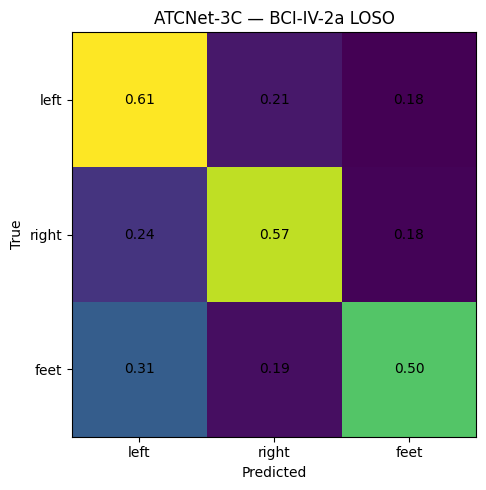

In [20]:
# ============================================================
# CELL 16 — CONFUSION MATRIX + CLASS REPORT
# ============================================================

if "fold_objects" in globals() and fold_objects:
    all_true = np.concatenate([
        fold_objects[s]["y_test"]
        for s in BCI_SUBJECTS
    ])
    all_pred = np.concatenate([
        fold_objects[s]["pred_test"]
        for s in BCI_SUBJECTS
    ])

    cm = confusion_matrix(
        all_true,
        all_pred,
        labels=list(range(N_CLASSES)),
        normalize="true",
    )

    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{c}" for c in CLASSES],
        columns=[f"pred_{c}" for c in CLASSES],
    )

    print("Normalized confusion matrix:")
    display(cm_df.round(3))

    print("\nClassification report:")
    print(
        classification_report(
            all_true,
            all_pred,
            labels=list(range(N_CLASSES)),
            target_names=CLASSES,
            digits=4,
        )
    )

    plt.figure(figsize=(6,5))
    plt.imshow(cm, interpolation="nearest")
    plt.xticks(range(N_CLASSES), CLASSES)
    plt.yticks(range(N_CLASSES), CLASSES)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("ATCNet-3C — BCI-IV-2a LOSO")
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            plt.text(j, i, f"{cm[i,j]:.2f}", ha="center", va="center")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "atcnet_loso_confusion_matrix.png", dpi=180)
    plt.show()


In [21]:
# ============================================================
# CELL 17 — LEARNING CURVES
# ============================================================

if "fold_objects" in globals() and fold_objects:
    # Plot only the first target as an example; all fold histories are retained.
    first_subject = BCI_SUBJECTS[0]
    h = fold_objects[first_subject]["history"]

    plt.figure(figsize=(8,5))
    plt.plot(h["epoch"], h["train_acc"], label="train")
    plt.plot(h["epoch"], h["val_acc"], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"ATCNet-3C Learning Curve — {first_subject}")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"atcnet_learning_curve_{first_subject}.png", dpi=180)
    plt.show()


KeyError: 'history'

In [ ]:
# ============================================================
# CELL 18 — SAVE RESULTS
# ============================================================

if "loso_results_df" in globals():
    csv_path = RESULT_DIR / "atcnet_3c_bci_iv_2a_loso_results.csv"
    loso_results_df.to_csv(csv_path, index=False)
    print("Saved:", csv_path)

if "fold_objects" in globals():
    pred_rows = []
    for subject, obj in fold_objects.items():
        for y_true, y_pred in zip(obj["y_test"], obj["pred_test"]):
            pred_rows.append({
                "subject": subject,
                "true_class": ID_TO_CLASS[int(y_true)],
                "pred_class": ID_TO_CLASS[int(y_pred)],
            })
    pred_df = pd.DataFrame(pred_rows)
    pred_path = RESULT_DIR / "atcnet_3c_bci_iv_2a_loso_predictions.csv"
    pred_df.to_csv(pred_path, index=False)
    print("Saved:", pred_path)

summary = {
    "model": "ATCNet-3C",
    "evaluation": "BCI-IV-2a within-dataset subject-independent LOSO",
    "subjects": BCI_SUBJECTS,
    "n_subjects": len(BCI_SUBJECTS),
    "n_channels": 22,
    "n_samples": 640,
    "sampling_rate_hz": 160.0,
    "classes": CLASSES,
    "n_windows": 5,
    "F1": 16,
    "D": 2,
    "temporal_kernel": 64,
    "pool1": 8,
    "pool2": 7,
    "attention_heads": 2,
    "tcn_depth": 2,
    "tcn_kernel": 4,
    "tcn_filters": 32,
    "learning_rate": 9e-4,
    "batch_size": 64,
    "epochs": 180,
}

summary_path = RESULT_DIR / "atcnet_3c_protocol.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Saved protocol:", summary_path)


## Interpretation and submission guardrail

The reference ATCNet repository reports **81.10%** on BCI Competition IV-2a using its refined Train–Val–Test implementation, and its code defines the ATCNet hyperparameters as `n_windows=5`, `F1=16`, `D=2`, temporal kernel 64, pool size 7, MHA, TCN depth 2, TCN kernel 4 and 32 filters. citeturn211482view0turn995181view2

This notebook keeps those architectural choices as closely as possible while changing only the project-specific interface from the original 22×1125/4-class setup to **22×640/3-class**. The outer evaluation remains true LOSO: one BCI subject is held out and never enters that fold's training/validation data. citeturn211482view0turn414876view0

Do not claim 70% or 80% until the **mean of the nine held-out subjects** is actually computed in Cell 14. The literature result is a benchmark, not a guarantee for this harmonized cache.